# 01 — Can gas exchange explain ocean carbon storage?

**Learning goals:** map boxes and arrows to a conserved carbon inventory;
infer background TA and distinguish a fit from a prediction; distinguish
equilibrium controls from rate controls.

Suppose you are testing your first ESBMTK atmosphere–ocean model. You build
two reservoirs: a finite atmosphere and one well-mixed ocean box.

Picture the initial ocean as water containing only dissolved NaCl, with
**TA = 0**. Dissolve a trace of CO2 to give it a small positive DIC concentration;
TA remains zero. Place almost all the remaining carbon in the atmosphere,
then let the two reservoirs exchange CO2. Nothing enters or leaves the system.
This is a fictional redistribution experiment, not a history of ocean formation.

Choose the total carbon inventory to equal that of an atmosphere at
**280 ppm CO2** plus an ocean with **DIC = 2040 µmol/kg**. Your hypothesis is:
**if the model is coded correctly, gas exchange should recover both reference
values.** You will predict, run, and assess that claim.

**Provisional time: 35 minutes.** Diagram and prediction (10); diagnosis and
TA calculation (15); comparisons and explanation (10). Use the PyCO2SYS skills
from 00 to write one complete TA calculation. Model construction, comparison
runs, plotting and budget checks are supplied. Give short answers.

Keep the [coding reference](../../ref/modelling_cheatsheet.md)
([two-page handout](../../output/pdf/modelling_cheatsheet.pdf)) beside the notebook.
Use it during the diagram activity; its separate tracer example is optional.
Code labels distinguish **Choose and explain** (your scientific choices),
**Understand and run** (supplied model steps), and **Supplied implementation**
(support code). Supplied steps still need interpretation; syntax memorisation
is not assessed. See [teaching goals and timing](../../TEACHING_GOALS.md).

In [1]:
# Supplied implementation: run this support code as provided.
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import PyCO2SYS as pyco2

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'teaching_config.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from teaching_config import TEACHING as config
from simple_models import (
    new_model, box_parameters, box_mass_kg, connect_atmosphere,
    single_box, inventories, audit,
)
from esbmtk import initialize_reservoirs, add_carbonate_system_1
from model import run_model
from teaching_plots import plot_ta_free, plot_partition_comparison, settling_time

## 1. Specify the system

```text
Atmosphere (xCO2; GasReservoir)
        ↓ J_gas,in       ↑ J_gas,out
        gas exchange: carbon only
Ocean (DIC, TA; initialize_reservoirs)
      carbonate system 1 → aqueous CO2
```

Both reservoirs are inside the system boundary. Write each carbon budget as
**inputs minus outputs**. The subscripts `atm` and `ocn` denote atmosphere
and ocean. Invasion, $J_{gas,in}(t)$, enters the ocean; outgassing,
$J_{gas,out}(t)$, leaves it:

$$\frac{dC_{atm}(t)}{dt}=J_{gas,out}(t)-J_{gas,in}(t),$$
$$m_{ocn}\frac{dDIC_{ocn}(t)}{dt}=J_{gas,in}(t)-J_{gas,out}(t).$$

Each flux is in mol C/yr. Ocean DIC is in mol/kg and water mass $m_{ocn}$ is
in kg. A transfer leaves one reservoir and enters the other by the same amount.
Gas exchange carries no TA, so the ocean TA inventory has zero tendency.

| Quantity | Role in this experiment |
| --- | --- |
| 280 ppm dry-air xCO2; 2040 µmol/kg DIC | Observed comparison targets |
| Ocean area and depth; atmospheric size; T/S/P | Independent inputs |
| Combined carbon inventory calculated from the targets | Target-derived constraint |
| Almost all carbon initially in the atmosphere | Fictional initial partition |
| Initial TA = 0 | Physical assumption to test |

The ocean has area $3.60\times10^{14}$ m² and depth 3750 m.
Uniform **T = 16 °C, S = 35 and P = 0 bar** and carbonate choices come from
`teaching_config.py`. The NaCl picture motivates the initial DIC and TA;
the calculation uses these supplied seawater chemistry settings.
ESBMTK uses bar and PyCO2SYS uses dbar; the configuration handles the conversion.
Density $\rho$ comes from ESBMTK at the same conditions.

With ocean volume $V_{ocn}$ and atmospheric size $N_{atm}$, the total carbon is

$$C_0=N_{atm}(280\times10^{-6})+\rho V_{ocn}(2040\times10^{-6}).$$

The two factors convert ppm to mol/mol and µmol/kg to mol/kg, respectively.
No geometry is fitted to a carbon ratio.

In [2]:
# Understand and run: trace this supplied step and interpret its evidence.
print('Shared chemistry:', config.pyco2)
print('Ocean volume (m3):', config.ocean_volume_m3)
print('ESBMTK density (kg/m3):', config.density_kg_m3)
print('Target-derived total carbon (mol):', config.total_carbon_mol)
INITIAL_DIC = 0.01  # umol/kg, small positive numerical seed
FIRST_TA = 0.0      # umol/kg: no background alkalinity

Shared chemistry: {'opt_k_carbonic': 10, 'opt_pH_scale': 2, 'opt_buffers_mode': 1, 'temperature': 16.0, 'salinity': 35.0, 'pressure': 0.0}
Ocean volume (m3): 1.35e+18
ESBMTK density (kg/m3): 1025.7484950008022
Target-derived total carbon (mol): 2.8744713552322094e+18


## 2. Build the supplied model

### 2.1 A finite atmosphere and an initial carbon partition

The atmosphere contains a fixed $N_{atm}=1.77\times10^{20}$ mol of air.
Its dry-air CO2 mole fraction, $x_{CO2}(t)$, changes during exchange;
$10^6x_{CO2}(t)$ gives ppm. Atmospheric carbon is
$C_{atm}(t)=N_{atm}x_{CO2}(t)$ mol C. No atmospheric height or volume is needed.

The initial ocean DIC is **0.01 µmol/kg**, a small positive numerical seed.
The remaining carbon starts in the atmosphere. With $m_{ocn}=\rho V_{ocn}$,

$$C_{atm}(0)=C_0-m_{ocn}DIC_{ocn}(0),\qquad
x_{CO2}(0)=\frac{C_0-m_{ocn}DIC_{ocn}(0)}{N_{atm}}.$$

Use DIC in mol/kg in these equations. The resulting initial atmosphere is
approximately **16,240 ppm**. The **280 ppm reference defines part of $C_0$**;
it is neither the initial concentration nor a fixed atmospheric boundary value.

### 2.2 Two directional fluxes, one net exchange

CO2 exchanges across the ocean area $A$ with piston velocity **4 m/day**.
The directional fluxes are

$$J_{gas,in}(t)=Av\rho\,\beta\,pCO_{2,atm}(t),\qquad
J_{gas,out}(t)=Av\rho\,[CO_2]_{aq}(t).$$

The solubility coefficient $\beta$ converts atmospheric pCO2 into a dissolved
CO2 concentration. Both $\beta pCO_{2,atm}$ and $[CO_2]_{aq}$ are in mol/kg.
With $A$ in m², $v$ converted to m/yr and $\rho$ in kg/m³, both fluxes are
in mol C/yr.

**Invasion** depends on atmospheric CO2 and the prescribed exchange and
solubility settings, independently of ocean DIC and TA. **Outgassing** depends
on aqueous CO2, which carbonate chemistry calculates from ocean DIC and TA.
The ocean gains their difference; the atmosphere loses the same amount:

$$J_{gas}(t)=J_{gas,in}(t)-J_{gas,out}(t).$$

Positive $J_{gas}$ means net ocean uptake; negative $J_{gas}$ means net
outgassing. At equilibrium the two directional rates balance, although both
remain nonzero. The closed budget is
$C_{atm}(t)+m_{ocn}DIC_{ocn}(t)=C_0$.

> **Units reference.** This follows the solubility-times-pCO2 notation in
> [the ESBMTK paper, equation 6](https://gmd.copernicus.org/articles/18/1155/2025/#section2.5).
> Our atmospheric state is dry-air mole fraction, not partial pressure.
> The supplied helper handles gas-convention and unit conversions through
> `solubility` and `scale`, using PyCO2SYS and ESBMTK density. You do not need
> to implement these conversions. The 0 bar setting is seawater pressure,
> not atmospheric pressure; solubility uses the shared 16 °C and salinity 35.

### 2.3 Map the diagram to objects

![Atmosphere-ocean code map: carbon transfers are solid arrows; carbonate-chemistry information links are dashed.](../../ref/figures/01_air_sea_code_map.png)

Read the code labels on the diagram alongside the construction below:

- `Model` supplies the clock and units. `M.CO2` is a species definition.
- `initialize_reservoirs` creates the ocean DIC and TA states. `box_parameters`
  supplies geometry (`g`), conditions (`T`, `S`, `P`) and initial concentrations (`c`).
- `add_carbonate_system_1` calculates `M.Ocean.CO2aq` from DIC and TA.
  This diagnostic informs gas exchange; it is not another carbon inventory.

Solid arrows transfer carbon. Dashed arrows supply information to a calculation.
The `.c` attribute stores concentration values: mol/kg for ocean states and
mol/mol for atmospheric CO2. Indices `[0]` and `[-1]` select the first and last
saved values.

First create the ocean and its carbonate chemistry:

In [ ]:
# Understand and run: trace this supplied step and interpret its evidence.
M = new_model(stop='2 kyr', max_timestep='1 yr')
initialize_reservoirs(M, {'Ocean': box_parameters(
    M, config.ocean_volume_m3, INITIAL_DIC, FIRST_TA)})
add_carbonate_system_1([M.Ocean])

### 2.4 Connect atmospheric CO2 to ocean DIC

The native constructor `Species2Species` connects two species states.
`source` and `sink` set the positive direction; `ctype` selects the flux law.
The supplied `connect_atmosphere` helper first creates the finite atmosphere,
then creates this connection. In the excerpt, `model` is `M` and `surface`
is `M.Ocean`; parameter values and conversions are supplied inside the helper.

```python
model.air_sea_exchange = Species2Species(
    source=model.CO2_At,
    sink=surface.DIC,
    species=model.CO2,
    ctype="gasexchange",
    piston_velocity=piston_velocity,
    solubility=f"{beta_native} mol/(m**3 * atm)",
    scale=surface.swc.density / 1000.0,
    ref_species=surface.CO2aq,
    id="air_sea",
)
```

`species` identifies the exchanged gas, while `sink` identifies the ocean DIC
state it changes. `ref_species` provides aqueous CO2 for the outgassing term.
The `gasexchange` law calculates the signed difference of invasion and
outgassing: **two conceptual arrows are represented by one connection**.

The next cell calls this helper and checks the endpoints, ocean mass and initial
TA. The connection is returned as `exchange`; the atmospheric state is `M.CO2_At`.

In [ ]:
# Understand and run: connect the atmosphere and check the construction.
exchange = connect_atmosphere(M, [M.Ocean])
assert exchange.source is M.CO2_At and exchange.sink is M.Ocean.DIC
np.testing.assert_allclose(box_mass_kg(M.Ocean),
                           config.ocean_volume_m3 * config.density_kg_m3, rtol=1e-12)
assert M.Ocean.TA.c[0] == 0
print('Initial atmosphere (ppm):', M.CO2_At.c[0] * 1e6)
print('Initial ocean carbon fraction:',
      box_mass_kg(M.Ocean) * M.Ocean.DIC.c[0] / config.total_carbon_mol)

### Before running: check the mapping and predict

Point to the ocean DIC/TA states and gas connection in the code. Which quantity
is calculated from DIC and TA? Add the two carbon tendencies in section 1:
why do the internal transfers cancel? Why must you multiply ocean concentration
by water mass when checking the carbon inventory?

<!-- BEGIN SOLUTION -->
`M.Ocean.DIC` and `M.Ocean.TA` are states; carbonate chemistry calculates
aqueous CO2. `connect_atmosphere` creates the atmosphere and its gas connection.
The ocean gains exactly what the atmosphere loses, so their carbon sum is
constant. mol/kg times kg is mol. TA has no source or sink in this model.
<!-- END SOLUTION -->

**Write a short prediction before running the next cell.** Does specifying
the combined carbon inventory guarantee recovery of both reference values?
What else might determine the final atmosphere–ocean partition?

In [ ]:
# Understand and run: trace this supplied step and interpret its evidence.
run_model(M)
print(audit(M))
print('TA-free result: xCO2 (ppm), DIC (umol/kg):',
      M.CO2_At.c[-1] * 1e6, M.Ocean.DIC.c[-1] * 1e6)
plot_ta_free(M, config)
# Verify the diagnosed mismatch before inferring TA.
assert abs(M.CO2_At.c[-1] * 1e6 - config.target_xco2_ppm) > 1000

### After running: diagnose the result

Revisit your prediction using the carbon and TA budget checks. Does disagreement
with the reference values demonstrate a coding error? What do passing budget
checks establish, and what do they leave untested?

Which initial chemical assumption prevents recovery of the reference partition?
Can any process represented in this model change it?

<!-- BEGIN SOLUTION -->
The total carbon fixes the combined inventory, not its equilibrium partition.
At fixed geometry and thermodynamic settings, that partition also depends on TA.
Gas exchange adds DIC but no TA, so the initial TA = 0 persists. At zero TA,
a much larger fraction of DIC is aqueous CO2 than in the buffered reference
state. The ocean therefore cannot retain the target DIC at 280 ppm. No process
in this model can generate the missing alkalinity. A small initial DIC does
not require zero TA; these are separate initial assumptions.

Passing carbon and TA checks supports correct budget implementation. It does
not prove complete code correctness or that the physical assumptions represent
the ocean. The mismatch alone is therefore not evidence of a coding error.
<!-- END SOLUTION -->

## 3. Infer TA, then test the revised model

**Exercise 01.1 — reuse your PyCO2SYS skills from 00.** Calculate the TA required
for seawater with **DIC = 2040 µmol/kg** to be in equilibrium with atmospheric
**dry-air xCO2 = 280 ppm**. Choose the input types, write the PyCO2SYS call and
extract TA. Save the result as **`inferred_ta`, in µmol/kg**.

Use `config.target_dic_umol_kg`, `config.target_xco2_ppm` and the supplied settings
`**config.pyco2`. These settings include **16 °C**, salinity 35, pressure 0 dbar and
the shared carbonate choices. Do not carry over 00's 15 °C baseline.
Consult your work from 00 and the
[PyCO2SYS input and result documentation](https://pyco2sys.readthedocs.io/en/latest/co2sys_nd/)
as needed. Dry-air xCO2 in ppm differs from pCO2 in µatm.

After calculating TA, explain what was fitted and why the result is
**not an independent prediction** of ocean TA.

<!-- BEGIN SOLUTION -->
TA is inferred from the two reference targets under the prescribed conditions.
It is a fitted background parameter, not an independent prediction. Recovering
the same targets in ESBMTK checks consistency between the implementations and
the prescribed carbon inventory; it does not independently validate the model.
<!-- END SOLUTION -->

In [ ]:
# Choose and explain: calculate TA from the two reference targets.
# Save inferred_ta in umol/kg; use the shared settings in config.pyco2.
# BEGIN SOLUTION
dic_input_type = 2
air_input_type = 9
reference = pyco2.sys(par1=config.target_dic_umol_kg, par1_type=dic_input_type,
                     par2=config.target_xco2_ppm, par2_type=air_input_type, **config.pyco2)
inferred_ta = float(reference['alkalinity'])
# END SOLUTION
print('Inferred TA (umol/kg):', inferred_ta)

### Run a fresh model with the inferred TA

Keep the same total carbon, geometry, initial DIC and piston velocity.
Change only the initial TA. This is a **calibration and software-consistency
check**, not an independent prediction of atmospheric xCO2.

The supplied [`single_box`](../../simple_models.py) helper repeats section 2's
construction: create a model, initialize the ocean, add carbonate chemistry,
and connect the atmosphere. It returns a **fresh, unrun model**; `run_model`
then runs it. Thus `buffered` is a separate experiment with a different initial
TA inventory, not an alkalinity addition during the first run.

Later, the same helper changes initial DIC or piston velocity. Changing initial
DIC adjusts atmospheric carbon automatically to preserve the total inventory.

In [ ]:
# Understand and run: test the revised initial TA with the supplied model.
buffered = single_box(ta_umol_kg=inferred_ta)
run_model(buffered)
print(audit(buffered))
np.testing.assert_allclose(buffered.CO2_At.c[-1] * 1e6, 280, atol=0.5)
np.testing.assert_allclose(buffered.Ocean.DIC.c[-1] * 1e6, 2040, atol=0.2)

## 4. Compare paths and endpoints

Predict the effect of two separate changes to the buffered model:

- Start with **1000 µmol/kg ocean DIC**, keeping total carbon and TA fixed.
- Halve the **piston velocity**, keeping the initial partition and TA fixed.

Then run the supplied comparison. Compare the curves and printed settling times.
Here, settling time is the first saved time after which atmospheric CO2 stays
within 1% of its final value. The code checks carbon and TA at every saved time.

Which change alters the initial partition, and which alters the exchange rate?
Does either change the eventual equilibrium?


ESBMTK 0.14.3.1.post0  
 Copyright (C) 2020 - 2026  Ulrich G.Wortmann
This program comes with ABSOLUTELY NO WARRANTY
This is free software, and you are welcome to redistribute it
under certain conditions; See the LICENSE file for details.

If you use ESBMTK for your research, please cite:

Wortmann et al. 2025, https://doi.org/10.5194/gmd-18-1155-2025


ESBMTK 0.14.3.1.post0  
 Copyright (C) 2020 - 2026  Ulrich G.Wortmann
This program comes with ABSOLUTELY NO WARRANTY
This is free software, and you are welcome to redistribute it
under certain conditions; See the LICENSE file for details.

If you use ESBMTK for your research, please cite:

Wortmann et al. 2025, https://doi.org/10.5194/gmd-18-1155-2025

status=0
message=The solver successfully reached the end of the integration interval.


 Execution took 0.53 CPU seconds, wall time = 0.54 seconds

{'carbon_relative_error': 2.137436502477746e-15, 'ta_change_mol': 0.0}
status=0
message=The solver successfully reached the end of the integ

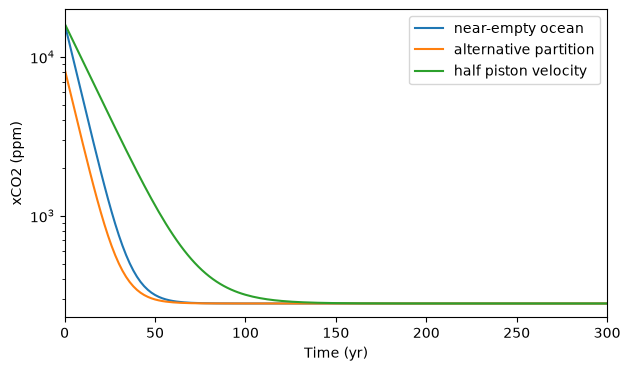

In [7]:
# Understand and run: trace this supplied step and interpret its evidence.
partition = single_box(ta_umol_kg=inferred_ta, initial_dic_umol_kg=1000)
slower = single_box(ta_umol_kg=inferred_ta, piston_velocity='2 m/d')
for case in (partition, slower):
    run_model(case)
    carbon, ta = inventories(case)
    np.testing.assert_allclose(carbon, config.total_carbon_mol, rtol=2e-6)
    np.testing.assert_allclose(ta, ta[0], rtol=2e-6)
    np.testing.assert_allclose(case.CO2_At.c[-1], buffered.CO2_At.c[-1], atol=0.5e-6)
    print(audit(case))

plot_partition_comparison(buffered, partition, slower)
assert settling_time(slower) > settling_time(buffered)


## 5. Explain what the experiment establishes

**Context:** real-ocean TA reflects processes including weathering, mineral
dissolution and carbonate burial. This closed model includes none of those
sources or sinks. Prescribing background TA does not simulate its origin;
those processes enter explicitly in 03/04.

**Finish 01 with three short sentences:**

1. Why does the TA-free mismatch alone not demonstrate a coding error?
2. What does the inferred TA represent, and what does the buffered rerun check?
3. Why do the initial-partition and piston-velocity experiments approach the
   same equilibrium despite following different paths?

<!-- BEGIN SOLUTION -->
The TA-free model can conserve carbon correctly while its assumed TA prevents
the reference partition. The inferred TA is fitted to the two targets, so the
buffered rerun checks chemistry and inventory consistency rather than providing
independent validation. At fixed total carbon, TA, geometry and chemistry,
initial partition changes the starting state and positive piston velocity
controls relaxation, but neither changes the gas-exchange equilibrium.
<!-- END SOLUTION -->

Continue to 02, which retains the same total carbon inventory.

> **Numerical reference.** The 0.01 µmol/kg DIC seed does not supply alkalinity.
> ESBMTK's carbonate-system-1 approximation can show transient pH discrepancies
> in extreme states (paper section 2.4). Here we check conserved inventories
> and stationary agreement; the extreme transient pH is not a realistic
> seawater history. The helper supplies the native gas-exchange routine's
> factor-of-1000 conversion; no additional student calculation is required.